In [1]:
library(tidyverse)  # Data wrangling packages.



── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [2]:
# This snippet assumes that you run setup first

# This code copies a file from your Google Bucket into a dataframe

# replace 'test.csv' with the name of the file in your google bucket (don't delete the quotation marks)
name_of_file_in_bucket <- 'Demographic_and_ancestry_covariates.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ", my_bucket, "/data/", name_of_file_in_bucket, " ."), intern=T)

# Load the file into a dataframe
demographics  <- read_csv(name_of_file_in_bucket)


character(0)

Rows: 162193 Columns: 28
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): SexGender, income, education, where_born, military, healthcare, di...
dbl  (9): person_id, race_unknown, age_today, LGBTQIA, ehr_length, relative_...
lgl  (8): AIAN, Asian, Black, Mid, Multiple, PI, White, His
date (3): date_of_birth, min_date, max_date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# Block 1: Is there a hypercholesterolemia Dx in EHR?

In [6]:
library(tidyverse)
library(bigrquery)

# This query represents dataset "hypercholesterolemia2" for domain "condition" and was generated for All of Us Controlled Tier Dataset v8
dataset_78270637_condition_sql <- paste("
    SELECT
        c_occurrence.person_id,
        c_occurrence.condition_concept_id,
        c_standard_concept.concept_name as standard_concept_name,
        c_standard_concept.concept_code as standard_concept_code,
        c_standard_concept.vocabulary_id as standard_vocabulary,
        c_occurrence.condition_start_datetime,
        c_occurrence.condition_end_datetime,
        c_occurrence.condition_type_concept_id,
        c_type.concept_name as condition_type_concept_name,
        c_occurrence.stop_reason,
        c_occurrence.visit_occurrence_id,
        visit.concept_name as visit_occurrence_concept_name,
        c_occurrence.condition_source_value,
        c_occurrence.condition_source_concept_id,
        c_source_concept.concept_name as source_concept_name,
        c_source_concept.concept_code as source_concept_code,
        c_source_concept.vocabulary_id as source_vocabulary,
        c_occurrence.condition_status_source_value,
        c_occurrence.condition_status_concept_id,
        c_status.concept_name as condition_status_concept_name 
    FROM
        ( SELECT
            * 
        FROM
            `condition_occurrence` c_occurrence 
        WHERE
            (
                condition_concept_id IN (SELECT
                    DISTINCT c.concept_id 
                FROM
                    `cb_criteria` c 
                JOIN
                    (SELECT
                        CAST(cr.id as string) AS id       
                    FROM
                        `cb_criteria` cr       
                    WHERE
                        concept_id IN (4029305)       
                        AND full_text LIKE '%_rank1]%'      ) a 
                        ON (c.path LIKE CONCAT('%.', a.id, '.%') 
                        OR c.path LIKE CONCAT('%.', a.id) 
                        OR c.path LIKE CONCAT(a.id, '.%') 
                        OR c.path = a.id) 
                WHERE
                    is_standard = 1 
                    AND is_selectable = 1)
            )  
            AND (
                c_occurrence.PERSON_ID IN (SELECT
                    distinct person_id  
                FROM
                    `cb_search_person` cb_search_person  
                WHERE
                    cb_search_person.person_id IN (SELECT
                        person_id 
                    FROM
                        `cb_search_person` p 
                    WHERE
                        has_whole_genome_variant = 1 ) 
                    AND cb_search_person.person_id IN (SELECT
                        person_id 
                    FROM
                        `cb_search_person` p 
                    WHERE
                        has_ehr_data = 1 ) )
            )) c_occurrence 
    LEFT JOIN
        `concept` c_standard_concept 
            ON c_occurrence.condition_concept_id = c_standard_concept.concept_id 
    LEFT JOIN
        `concept` c_type 
            ON c_occurrence.condition_type_concept_id = c_type.concept_id 
    LEFT JOIN
        `visit_occurrence` v 
            ON c_occurrence.visit_occurrence_id = v.visit_occurrence_id 
    LEFT JOIN
        `concept` visit 
            ON v.visit_concept_id = visit.concept_id 
    LEFT JOIN
        `concept` c_source_concept 
            ON c_occurrence.condition_source_concept_id = c_source_concept.concept_id 
    LEFT JOIN
        `concept` c_status 
            ON c_occurrence.condition_status_concept_id = c_status.concept_id", sep="")

# Formulate a Cloud Storage destination path for the data exported from BigQuery.
# NOTE: By default data exported multiple times on the same day will overwrite older copies.
#       But data exported on a different days will write to a new location so that historical
#       copies can be kept as the dataset definition is changed.
condition_78270637_path <- file.path(
  Sys.getenv("WORKSPACE_BUCKET"),
  "bq_exports",
  Sys.getenv("OWNER_EMAIL"),
  strftime(lubridate::now(), "%Y%m%d"),  # Comment out this line if you want the export to always overwrite.
  "condition_78270637",
  "condition_78270637_*.csv")
message(str_glue('The data will be written to {condition_78270637_path}. Use this path when reading ',
                 'the data into your notebooks in the future.'))

# Perform the query and export the dataset to Cloud Storage as CSV files.
# NOTE: You only need to run `bq_table_save` once. After that, you can
#       just read data from the CSVs in Cloud Storage.
bq_table_save(
  bq_dataset_query(Sys.getenv("WORKSPACE_CDR"), dataset_78270637_condition_sql, billing = Sys.getenv("GOOGLE_PROJECT")),
  condition_78270637_path,
  destination_format = "CSV")


# Read the data directly from Cloud Storage into memory.
# NOTE: Alternatively you can `gsutil -m cp {condition_78270637_path}` to copy these files
#       to the Jupyter disk.
read_bq_export_from_workspace_bucket <- function(export_path) {
  col_types <- cols(standard_concept_name = col_character(), standard_concept_code = col_character(), standard_vocabulary = col_character(), condition_type_concept_name = col_character(), stop_reason = col_character(), visit_occurrence_concept_name = col_character(), condition_source_value = col_character(), source_concept_name = col_character(), source_concept_code = col_character(), source_vocabulary = col_character(), condition_status_source_value = col_character(), condition_status_concept_name = col_character())
  bind_rows(
    map(system2('gsutil', args = c('ls', export_path), stdout = TRUE, stderr = TRUE),
        function(csv) {
          message(str_glue('Loading {csv}.'))
          chunk <- read_csv(pipe(str_glue('gsutil cat {csv}')), col_types = col_types, show_col_types = FALSE)
          if (is.null(col_types)) {
            col_types <- spec(chunk)
          }
          chunk
        }))
}
condition_df <- read_bq_export_from_workspace_bucket(condition_78270637_path)

table(condition_df$standard_concept_name)

condition_df <- subset(condition_df, !grepl("lipoproteinemia", standard_concept_name, ignore.case=TRUE))

table(condition_df$standard_concept_name)

The data will be written to gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/condition_78270637/condition_78270637_*.csv. Use this path when reading the data into your notebooks in the future.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/condition_78270637/condition_78270637_000000000000.csv.




            Familial hypercholesterolemia 
                                     6198 
Fredrickson type IIa hyperlipoproteinemia 
                                        1 
                Hyperalphalipoproteinemia 
                                        6 
                     Hypercholesterolemia 
                                    13679 
             Primary hypercholesterolemia 
                                       28 
                Pure hypercholesterolemia 
                                   593148 


Familial hypercholesterolemia          Hypercholesterolemia 
                         6198                         13679 
 Primary hypercholesterolemia     Pure hypercholesterolemia 
                           28                        593148 

In [7]:
# Create a new column 'block_1' and initialize it with FALSE
demographics$block_1 <- FALSE

# Find the 'person_id' values that are in 'condition_df'
matching_person_ids <- demographics$person_id %in% condition_df$person_id

# Assign TRUE to 'block_1' for matching 'person_id'
demographics$block_1[matching_person_ids] <- TRUE

# Print the resulting dataframe
table(demographics$block_1)


 FALSE   TRUE 
131649  30544 

# Block 2: Was the patient prescribed hypercholesterolemia medication?

In [8]:
library(tidyverse)
library(bigrquery)

# This query represents dataset "HyperC_drug_exposures" for domain "drug" and was generated for All of Us Controlled Tier Dataset v7
dataset_45778450_drug_sql <- paste("
    SELECT
        d_exposure.person_id,
        d_exposure.drug_concept_id,
        d_standard_concept.concept_name as standard_concept_name,
        d_standard_concept.concept_code as standard_concept_code,
        d_standard_concept.vocabulary_id as standard_vocabulary,
        d_exposure.drug_exposure_start_datetime,
        d_exposure.drug_exposure_end_datetime,
        d_exposure.verbatim_end_date,
        d_exposure.drug_type_concept_id,
        d_type.concept_name as drug_type_concept_name,
        d_exposure.stop_reason,
        d_exposure.refills,
        d_exposure.quantity,
        d_exposure.days_supply,
        d_exposure.sig,
        d_exposure.route_concept_id,
        d_route.concept_name as route_concept_name,
        d_exposure.lot_number,
        d_exposure.visit_occurrence_id,
        d_visit.concept_name as visit_occurrence_concept_name,
        d_exposure.drug_source_value,
        d_exposure.drug_source_concept_id,
        d_source_concept.concept_name as source_concept_name,
        d_source_concept.concept_code as source_concept_code,
        d_source_concept.vocabulary_id as source_vocabulary,
        d_exposure.route_source_value,
        d_exposure.dose_unit_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `drug_exposure` d_exposure 
        WHERE
            (
                drug_concept_id IN (
                    SELECT
                        DISTINCT ca.descendant_id 
                    FROM
                        `cb_criteria_ancestor` ca 
                    JOIN
                        (
                            SELECT
                                DISTINCT c.concept_id       
                            FROM
                                `cb_criteria` c       
                            JOIN
                                (
                                    SELECT
                                        CAST(cr.id as string) AS id             
                                    FROM
                                        `cb_criteria` cr             
                                    WHERE
                                        concept_id IN (
                                            21601853
                                        )             
                                        AND full_text LIKE '%_rank1]%'       
                                ) a 
                                    ON (
                                        c.path LIKE CONCAT('%.',
                                    a.id,
                                    '.%') 
                                    OR c.path LIKE CONCAT('%.',
                                    a.id) 
                                    OR c.path LIKE CONCAT(a.id,
                                    '.%') 
                                    OR c.path = a.id) 
                                WHERE
                                    is_standard = 1 
                                    AND is_selectable = 1
                                ) b 
                                    ON (
                                        ca.ancestor_id = b.concept_id
                                    )
                            )
                        )  
                        AND (
                            d_exposure.PERSON_ID IN (
                                SELECT
                                    distinct person_id  
                            FROM
                                `cb_search_person` cb_search_person  
                            WHERE
                                cb_search_person.person_id IN (
                                    SELECT
                                        person_id 
                                    FROM
                                        `cb_search_person` p 
                                    WHERE
                                        has_whole_genome_variant = 1 
                                ) 
                                AND cb_search_person.person_id IN (
                                    SELECT
                                        person_id 
                                    FROM
                                        `cb_search_person` p 
                                    WHERE
                                        has_ehr_data = 1 
                                ) 
                            )
                        )
                ) d_exposure 
            LEFT JOIN
                `concept` d_standard_concept 
                    ON d_exposure.drug_concept_id = d_standard_concept.concept_id 
            LEFT JOIN
                `concept` d_type 
                    ON d_exposure.drug_type_concept_id = d_type.concept_id 
            LEFT JOIN
                `concept` d_route 
                    ON d_exposure.route_concept_id = d_route.concept_id 
            LEFT JOIN
                `visit_occurrence` v 
                    ON d_exposure.visit_occurrence_id = v.visit_occurrence_id 
            LEFT JOIN
                `concept` d_visit 
                    ON v.visit_concept_id = d_visit.concept_id 
            LEFT JOIN
                `concept` d_source_concept 
                    ON d_exposure.drug_source_concept_id = d_source_concept.concept_id", sep="")

# Formulate a Cloud Storage destination path for the data exported from BigQuery.
# NOTE: By default data exported multiple times on the same day will overwrite older copies.
#       But data exported on a different days will write to a new location so that historical
#       copies can be kept as the dataset definition is changed.
drug_45778450_path <- file.path(
  Sys.getenv("WORKSPACE_BUCKET"),
  "bq_exports",
  Sys.getenv("OWNER_EMAIL"),
  strftime(lubridate::now(), "%Y%m%d"),  # Comment out this line if you want the export to always overwrite.
  "drug_45778450",
  "drug_45778450_*.csv")
message(str_glue('The data will be written to {drug_45778450_path}. Use this path when reading ',
                 'the data into your notebooks in the future.'))

# Perform the query and export the dataset to Cloud Storage as CSV files.
# NOTE: You only need to run `bq_table_save` once. After that, you can
#       just read data from the CSVs in Cloud Storage.
bq_table_save(
  bq_dataset_query(Sys.getenv("WORKSPACE_CDR"), dataset_45778450_drug_sql, billing = Sys.getenv("GOOGLE_PROJECT")),
  drug_45778450_path,
  destination_format = "CSV")

# Read the data directly from Cloud Storage into memory.
# NOTE: Alternatively you can `gsutil -m cp {drug_45778450_path}` to copy these files
#       to the Jupyter disk.
read_bq_export_from_workspace_bucket <- function(export_path) {
  col_types <- cols(standard_concept_name = col_character(), standard_concept_code = col_character(), standard_vocabulary = col_character(), drug_type_concept_name = col_character(), stop_reason = col_character(), sig = col_character(), route_concept_name = col_character(), lot_number = col_character(), visit_occurrence_concept_name = col_character(), drug_source_value = col_character(), source_concept_name = col_character(), source_concept_code = col_character(), source_vocabulary = col_character(), route_source_value = col_character(), dose_unit_source_value = col_character())
  bind_rows(
    map(system2('gsutil', args = c('ls', export_path), stdout = TRUE, stderr = TRUE),
        function(csv) {
          message(str_glue('Loading {csv}.'))
          chunk <- read_csv(pipe(str_glue('gsutil cat {csv}')), col_types = col_types, show_col_types = FALSE)
          if (is.null(col_types)) {
            col_types <- spec(chunk)
          }
          chunk
        }))
}
drug_df <- read_bq_export_from_workspace_bucket(drug_45778450_path)

unique(drug_df$standard_concept_name)

The data will be written to gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/drug_45778450/drug_45778450_*.csv. Use this path when reading the data into your notebooks in the future.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/drug_45778450/drug_45778450_000000000000.csv.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/drug_45778450/drug_45778450_000000000001.csv.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/drug_45778450/drug_45778450_000000000002.csv.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/drug_45778450/drug_45778450_000000000003.csv.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/drug_45

[1] "amlodipine 5 MG / benazepril hydrochloride 10 MG Oral Capsule"                                                                                                                                                                                                  
  [2] "valsartan 160 MG Oral Tablet"                                                                                                                                                                                                                                   
  [3] "aspirin 325 MG Delayed Release Oral Tablet [Ecotrin]"                                                                                                                                                                                                           
  [4] "aspirin 81 MG Delayed Release Oral Tablet [Ecotrin]"                                                                                                                                                                                                            
  [5] "colestipol"                                                                                                                                                                                                                                                     
  [6] "niacin 500 MG Extended Release Oral Capsule"                                                                                                                                                                                                                    
  [7] "fenofibrate 145 MG Oral Tablet"                                                                                                                                                                                                                                 
  [8] "hydrochlorothiazide 25 MG / lisinopril 20 MG Oral Tablet"                                                                                                                                                                                                       
  [9] "omega-3 fatty acids"                                                                                                                                                                                                                                            
 [10] "lisinopril 30 MG Oral Tablet"                                                                                                                                                                                                                                   
 [11] "pravastatin sodium 10 MG Oral Tablet"                                                                                                                                                                                                                           
 [12] "rosuvastatin calcium 20 MG Oral Tablet [Crestor]"                                                                                                                                                                                                               
 [13] "lovastatin 10 MG Oral Tablet"                                                                                                                                                                                                                                   
 [14] "sacubitril 24 MG / valsartan 26 MG Oral Tablet"                                                                                                                                                                                                                 
 [15] "niacin"                                                                                                                                                                                                                                                         
 [16] "aspirin 500 MG / caffeine 65 MG Eff

In [15]:
exclude_terms <- c("Ambulatory", "Emergency", "Inpatient", "Living", "examination", "Hospital", "Nursing", "Observation", "Employment", "Hospice", "Intensive")
drug_df <- subset(drug_df, !grepl(paste(exclude_terms, collapse="|"), visit_occurrence_concept_name, ignore.case=TRUE))
table(drug_df$visit_occurrence_concept_name)


              Case Management Visit                          Home Visit 
                                  1                                 259 
                   Laboratory Visit                        Office Visit 
                              10256                              199628 
                   Outpatient Visit                            Pharmacy 
                            1638671                                 176 
                     Pharmacy visit                          Telehealth 
                              49782                               31148 
Unknown Value (but present in data) 
                                106 

In [16]:
# Create a new column 'block_2' and initialize it with FALSE
demographics$block_2 <- FALSE

# Find the 'person_id' values that are in 'condition_df'
matching_person_ids <- demographics$person_id %in% drug_df$person_id

# Assign TRUE to 'block_1' for matching 'person_id'
demographics$block_2[matching_person_ids] <- TRUE

# Print the resulting dataframe
table(demographics$block_2)


FALSE  TRUE 
84378 77815 

In [17]:
# Create a new column 'block_2b' and initialize it with FALSE
demographics$block_2b <- FALSE

# Count the number of occurrences of each 'person_id' in 'drug_df'
person_id_counts <- table(drug_df$person_id)

# Identify 'person_id' with at least 2 entries
person_ids_with_two_entries <- names(person_id_counts[person_id_counts >= 2])

# Update 'block_2b' to TRUE for people with at least 2 entries
demographics$block_2b <- demographics$person_id %in% person_ids_with_two_entries

# Print the resulting dataframe
table(demographics$block_2b)


FALSE  TRUE 
92798 69395 

# Block 3: Is there a hypercholesterolemia Dx in EHR, appearing at least twice?

In [12]:
number_condition_entries <- condition_df %>%
  group_by(person_id) %>%
  summarise(unique_conditions = n_distinct(condition_start_datetime))

condition_df2 <- number_condition_entries[number_condition_entries$unique_conditions>=2, ]


In [13]:
# Create a new column 'block_3' and initialize it with FALSE
demographics$block_3 <- FALSE

# Find the 'person_id' values that are in 'condition_df'
matching_person_ids <- demographics$person_id %in% condition_df2$person_id

# Assign TRUE to 'block_3' for matching 'person_id'
demographics$block_3[matching_person_ids] <- TRUE

# Print the resulting dataframe
table(demographics$block_3)


 FALSE   TRUE 
140375  21818 

# Block 4: Is there a record of abnormal cholesterol labs?

In [18]:
library(tidyverse)
library(bigrquery)

# This query represents dataset "LDL-C_labs" for domain "measurement" and was generated for All of Us Controlled Tier Dataset v7
dataset_96942568_measurement_sql <- paste("
    SELECT
        measurement.person_id,
        measurement.measurement_concept_id,
        m_standard_concept.concept_name as standard_concept_name,
        m_standard_concept.concept_code as standard_concept_code,
        m_standard_concept.vocabulary_id as standard_vocabulary,
        measurement.measurement_datetime,
        measurement.measurement_type_concept_id,
        m_type.concept_name as measurement_type_concept_name,
        measurement.operator_concept_id,
        m_operator.concept_name as operator_concept_name,
        measurement.value_as_number,
        measurement.value_as_concept_id,
        m_value.concept_name as value_as_concept_name,
        measurement.unit_concept_id,
        m_unit.concept_name as unit_concept_name,
        measurement.range_low,
        measurement.range_high,
        measurement.visit_occurrence_id,
        m_visit.concept_name as visit_occurrence_concept_name,
        measurement.measurement_source_value,
        measurement.measurement_source_concept_id,
        m_source_concept.concept_name as source_concept_name,
        m_source_concept.concept_code as source_concept_code,
        m_source_concept.vocabulary_id as source_vocabulary,
        measurement.unit_source_value,
        measurement.value_source_value 
    FROM
        ( SELECT
            * 
        FROM
            `measurement` measurement 
        WHERE
            (
                measurement_concept_id IN (
                    SELECT
                        DISTINCT c.concept_id 
                    FROM
                        `cb_criteria` c 
                    JOIN
                        (
                            SELECT
                                CAST(cr.id as string) AS id       
                            FROM
                                `cb_criteria` cr       
                            WHERE
                                concept_id IN (
                                    40795800
                                )       
                                AND full_text LIKE '%_rank1]%'      
                        ) a 
                            ON (
                                c.path LIKE CONCAT('%.',
                            a.id,
                            '.%') 
                            OR c.path LIKE CONCAT('%.',
                            a.id) 
                            OR c.path LIKE CONCAT(a.id,
                            '.%') 
                            OR c.path = a.id) 
                        WHERE
                            is_standard = 1 
                            AND is_selectable = 1
                        )
                )  
                AND (
                    measurement.PERSON_ID IN (
                        SELECT
                            distinct person_id  
                        FROM
                            `cb_search_person` cb_search_person  
                        WHERE
                            cb_search_person.person_id IN (
                                SELECT
                                    person_id 
                                FROM
                                    `cb_search_person` p 
                                WHERE
                                    has_whole_genome_variant = 1 
                            ) 
                            AND cb_search_person.person_id IN (
                                SELECT
                                    person_id 
                                FROM
                                    `cb_search_person` p 
                                WHERE
                                    has_ehr_data = 1 
                            ) 
                        )
                    )
            ) measurement 
        LEFT JOIN
            `concept` m_standard_concept 
                ON measurement.measurement_concept_id = m_standard_concept.concept_id 
        LEFT JOIN
            `concept` m_type 
                ON measurement.measurement_type_concept_id = m_type.concept_id 
        LEFT JOIN
            `concept` m_operator 
                ON measurement.operator_concept_id = m_operator.concept_id 
        LEFT JOIN
            `concept` m_value 
                ON measurement.value_as_concept_id = m_value.concept_id 
        LEFT JOIN
            `concept` m_unit 
                ON measurement.unit_concept_id = m_unit.concept_id 
        LEFT JOIn
            `visit_occurrence` v 
                ON measurement.visit_occurrence_id = v.visit_occurrence_id 
        LEFT JOIN
            `concept` m_visit 
                ON v.visit_concept_id = m_visit.concept_id 
        LEFT JOIN
            `concept` m_source_concept 
                ON measurement.measurement_source_concept_id = m_source_concept.concept_id", sep="")

# Formulate a Cloud Storage destination path for the data exported from BigQuery.
# NOTE: By default data exported multiple times on the same day will overwrite older copies.
#       But data exported on a different days will write to a new location so that historical
#       copies can be kept as the dataset definition is changed.
measurement_96942568_path <- file.path(
  Sys.getenv("WORKSPACE_BUCKET"),
  "bq_exports",
  Sys.getenv("OWNER_EMAIL"),
  strftime(lubridate::now(), "%Y%m%d"),  # Comment out this line if you want the export to always overwrite.
  "measurement_96942568",
  "measurement_96942568_*.csv")
message(str_glue('The data will be written to {measurement_96942568_path}. Use this path when reading ',
                 'the data into your notebooks in the future.'))

# Perform the query and export the dataset to Cloud Storage as CSV files.
# NOTE: You only need to run `bq_table_save` once. After that, you can
#       just read data from the CSVs in Cloud Storage.
bq_table_save(
  bq_dataset_query(Sys.getenv("WORKSPACE_CDR"), dataset_96942568_measurement_sql, billing = Sys.getenv("GOOGLE_PROJECT")),
  measurement_96942568_path,
  destination_format = "CSV")

# Read the data directly from Cloud Storage into memory.
# NOTE: Alternatively you can `gsutil -m cp {measurement_96942568_path}` to copy these files
#       to the Jupyter disk.
read_bq_export_from_workspace_bucket <- function(export_path) {
  col_types <- cols(standard_concept_name = col_character(), standard_concept_code = col_character(), standard_vocabulary = col_character(), measurement_type_concept_name = col_character(), operator_concept_name = col_character(), value_as_concept_name = col_character(), unit_concept_name = col_character(), visit_occurrence_concept_name = col_character(), measurement_source_value = col_character(), source_concept_name = col_character(), source_concept_code = col_character(), source_vocabulary = col_character(), unit_source_value = col_character(), value_source_value = col_character())
  bind_rows(
    map(system2('gsutil', args = c('ls', export_path), stdout = TRUE, stderr = TRUE),
        function(csv) {
          message(str_glue('Loading {csv}.'))
          chunk <- read_csv(pipe(str_glue('gsutil cat {csv}')), col_types = col_types, show_col_types = FALSE)
          if (is.null(col_types)) {
            col_types <- spec(chunk)
          }
          chunk
        }))
}
ldl_df <- read_bq_export_from_workspace_bucket(measurement_96942568_path)

dim(ldl_df)

head(ldl_df, 5)

The data will be written to gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/measurement_96942568/measurement_96942568_*.csv. Use this path when reading the data into your notebooks in the future.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/measurement_96942568/measurement_96942568_000000000000.csv.



[1] 1261640      26

person_id,measurement_concept_id,standard_concept_name,standard_concept_code,standard_vocabulary,measurement_datetime,measurement_type_concept_id,measurement_type_concept_name,operator_concept_id,operator_concept_name,⋯,range_high,visit_occurrence_id,visit_occurrence_concept_name,measurement_source_value,measurement_source_concept_id,source_concept_name,source_concept_code,source_vocabulary,unit_source_value,value_source_value
<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<chr>,⋯,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
1380452,3028288,Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation,13457-7,LOINC,2004-04-29 16:52:00 UTC,32817,EHR,NA,NA,⋯,100,NA,NA,NA,NA,NA,NA,NA,mg/dL,NA
4503815,3028288,Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation,13457-7,LOINC,2020-09-10 15:51:00 UTC,32817,EHR,NA,NA,⋯,100,NA,NA,NA,NA,NA,NA,NA,mg/dL,NA
7065152,3028288,Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation,13457-7,LOINC,2016-05-11 15:36:00 UTC,32817,EHR,NA,NA,⋯,130,NA,NA,NA,NA,NA,NA,NA,mg/dL,NA
8731247,3028288,Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation,13457-7,LOINC,2015-05-08 13:28:00 UTC,32817,EHR,NA,NA,⋯,100,NA,NA,NA,NA,NA,NA,NA,mg/dL,NA
5473152,3028288,Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation,13457-7,LOINC,2015-10-19 12:34:00 UTC,32817,EHR,NA,NA,⋯,99,NA,NA,NA,NA,NA,NA,NA,mg/dL,NA


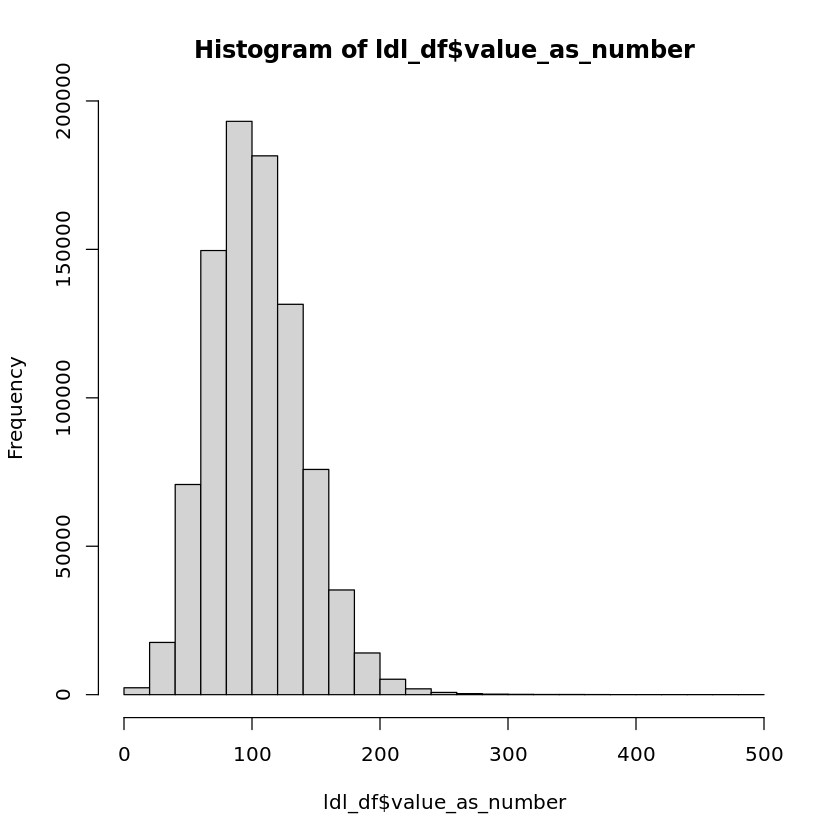

In [20]:
ldl_df <- ldl_df %>%
                filter(unit_source_value == 258797006 | unit_source_value == "mg/dL") |>
                      filter(standard_concept_name %in% c("Cholesterol in LDL [Mass/volume] in Serum or Plasma", 
                                      "Cholesterol in LDL [Mass/volume] in Serum or Plasma by calculation"))

ldl_df<-ldl_df[complete.cases(ldl_df$value_as_number), ] 

ldl_df=ldl_df[ldl_df$value_as_number<500,]
ldl_df=ldl_df[ldl_df$value_as_number>0,]

hist(ldl_df$value_as_number)

In [21]:
# Create a new column 'block_4' and initialize it with FALSE
demographics$block_4a <- FALSE
demographics$block_4b <- FALSE

#A will be for cases with high cholestrol, 
#B will be for controls without high cholestorol - middle cases are cut out

# Find the 'person_id' values that are in 'condition_df'
ldl_dfa=ldl_df[ldl_df$value_as_number>=160,]
matching_person_idsa <- demographics$person_id %in% ldl_dfa$person_id

ldl_dfb=ldl_df[ldl_df$value_as_number<=100,]
matching_person_idsb <- demographics$person_id %in% ldl_dfb$person_id

# Assign TRUE to 'block_' for matching 'person_id'
demographics$block_4a[matching_person_idsa] <- TRUE
demographics$block_4b[matching_person_idsb] <- TRUE

# Print the resulting dataframe
table(demographics$block_4a)
table(demographics$block_4b)


 FALSE   TRUE 
146724  15469 


 FALSE   TRUE 
101713  60480 

# Block 5: Self-report high cholesterol in survey

In [22]:
library(tidyverse)
library(bigrquery)

# This query represents dataset "cholesterol survey" for domain "survey" and was generated for All of Us Controlled Tier Dataset v7
dataset_76320189_survey_sql <- paste("
    SELECT
        answer.person_id,
        answer.survey_datetime,
        answer.survey,
        answer.question_concept_id,
        answer.question,
        answer.answer_concept_id,
        answer.answer,
        answer.survey_version_concept_id,
        answer.survey_version_name  
    FROM
        `ds_survey` answer   
    WHERE
        (
            question_concept_id IN (
                43528563, 43528793, 43530309, 43530467, 836836
            )
        )  
        AND (
            answer.PERSON_ID IN (
                SELECT
                    distinct person_id  
                FROM
                    `cb_search_person` cb_search_person  
                WHERE
                    cb_search_person.person_id IN (
                        SELECT
                            person_id 
                        FROM
                            `cb_search_person` p 
                        WHERE
                            has_whole_genome_variant = 1 
                    ) 
                    AND cb_search_person.person_id IN (
                        SELECT
                            person_id 
                        FROM
                            `cb_search_person` p 
                        WHERE
                            has_ehr_data = 1 
                    ) 
                )
            )", sep="")

# Formulate a Cloud Storage destination path for the data exported from BigQuery.
# NOTE: By default data exported multiple times on the same day will overwrite older copies.
#       But data exported on a different days will write to a new location so that historical
#       copies can be kept as the dataset definition is changed.
survey_76320189_path <- file.path(
  Sys.getenv("WORKSPACE_BUCKET"),
  "bq_exports",
  Sys.getenv("OWNER_EMAIL"),
  strftime(lubridate::now(), "%Y%m%d"),  # Comment out this line if you want the export to always overwrite.
  "survey_76320189",
  "survey_76320189_*.csv")
message(str_glue('The data will be written to {survey_76320189_path}. Use this path when reading ',
                 'the data into your notebooks in the future.'))

# Perform the query and export the dataset to Cloud Storage as CSV files.
# NOTE: You only need to run `bq_table_save` once. After that, you can
#       just read data from the CSVs in Cloud Storage.
bq_table_save(
  bq_dataset_query(Sys.getenv("WORKSPACE_CDR"), dataset_76320189_survey_sql, billing = Sys.getenv("GOOGLE_PROJECT")),
  survey_76320189_path,
  destination_format = "CSV")

# Read the data directly from Cloud Storage into memory.
# NOTE: Alternatively you can `gsutil -m cp {survey_76320189_path}` to copy these files
#       to the Jupyter disk.
read_bq_export_from_workspace_bucket <- function(export_path) {
  col_types <- cols(survey = col_character(), question = col_character(), answer = col_character(), survey_version_name = col_character())
  bind_rows(
    map(system2('gsutil', args = c('ls', export_path), stdout = TRUE, stderr = TRUE),
        function(csv) {
          message(str_glue('Loading {csv}.'))
          chunk <- read_csv(pipe(str_glue('gsutil cat {csv}')), col_types = col_types, show_col_types = FALSE)
          if (is.null(col_types)) {
            col_types <- spec(chunk)
          }
          chunk
        }))
}
survey_df <- read_bq_export_from_workspace_bucket(survey_76320189_path)


The data will be written to gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/survey_76320189/survey_76320189_*.csv. Use this path when reading the data into your notebooks in the future.

Loading gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/bq_exports/micah_hysong@researchallofus.org/20250825/survey_76320189/survey_76320189_000000000000.csv.



In [23]:
survey_df<-survey_df[survey_df$question=="About how old were you when you were first told you had high cholesterol?", ]

# Create a new column 'block_5' and initialize it with FALSE
demographics$block_5 <- FALSE

# Find the 'person_id' values that are in 'condition_df'
matching_person_ids <- demographics$person_id %in% survey_df$person_id

# Assign TRUE to 'block_1' for matching 'person_id'
demographics$block_5[matching_person_ids] <- TRUE

# Print the resulting dataframe
head(demographics)
table(demographics$block_5)

person_id,date_of_birth,AIAN,Asian,Black,Mid,Multiple,PI,White,His,⋯,record_depth,visit_frequency,age_at_last_event,block_1,block_2,block_2b,block_3,block_4a,block_4b,block_5
<dbl>,<date>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,⋯,<dbl>,<dbl>,<dbl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>,<lgl>
2163605,1966-06-15,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,⋯,260,0.053072056,57,FALSE,TRUE,TRUE,FALSE,FALSE,TRUE,FALSE
1710103,1952-06-15,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,⋯,120,0.019717384,71,TRUE,TRUE,TRUE,TRUE,TRUE,TRUE,FALSE
1994163,1957-06-15,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,⋯,44,0.015697467,66,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE
2597127,1959-06-15,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,⋯,33,0.007608946,64,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE
1795976,1964-06-15,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,⋯,104,0.013495977,57,TRUE,TRUE,TRUE,TRUE,FALSE,FALSE,FALSE
2909655,1962-06-15,FALSE,FALSE,FALSE,FALSE,FALSE,TRUE,FALSE,FALSE,⋯,140,0.043424318,61,FALSE,TRUE,TRUE,FALSE,FALSE,FALSE,TRUE



 FALSE   TRUE 
136181  26012 

# Get Cases

In [24]:
row_counts <- rowSums(demographics[, c("block_1", "block_2", "block_3", "block_4a", "block_5")])
demographics$case1 <- row_counts >= 2
sum(demographics$case1)

row_counts <- rowSums(demographics[, c("block_1", "block_2", "block_3", "block_4a")])
demographics$case2 <- row_counts >= 2
sum(demographics$case2)

row_counts <- rowSums(demographics[, c("block_1", "block_2b", "block_3", "block_4a", "block_5")])
demographics$case3 <- row_counts >= 2
sum(demographics$case3)

row_counts <- rowSums(demographics[, c("block_1", "block_2b", "block_3", "block_4a")])
demographics$case4 <- row_counts >= 2
sum(demographics$case4)

[1] 44988

[1] 35191

[1] 43712

[1] 34431

# Get Controls


In [26]:
# Define control condition
demographics$control1 <- with(demographics,
    block_1 == 0 & block_2 == 0 & block_4b == 1 & block_5 == 0
)

# Count how many rows satisfy it
sum(demographics$control1)


# Define control condition
demographics$control2 <- with(demographics,
    block_1 == 0 & block_2 == 0 & block_4b == 1
)

# Count how many rows satisfy it
sum(demographics$control2)

[1] 13714

[1] 14463

In [27]:
# Includes survey 
demographics <- demographics %>%
  mutate(case_def1 = case_when(
    control1 == TRUE ~ 0,  # If control1 is TRUE, new_column is 0
    case1 == TRUE ~ 1,     # If case1 is TRUE, new_column is 1
    TRUE ~ NA_real_        # If neither is TRUE, you could assign NA or another value
  ))

# Excludes survey 
demographics <- demographics %>%
  mutate(case_def2 = case_when(
    control2 == TRUE ~ 0,  # If control1 is TRUE, new_column is 0
    case2 == TRUE ~ 1,     # If case1 is TRUE, new_column is 1
    TRUE ~ NA_real_        # If neither is TRUE, you could assign NA or another value
  ))

# Stricter medication criteria, with survey
demographics <- demographics %>%
  mutate(case_def3 = case_when(
    control1 == TRUE ~ 0,  # If control1 is TRUE, new_column is 0
    case3 == TRUE ~ 1,     # If case1 is TRUE, new_column is 1
    TRUE ~ NA_real_        # If neither is TRUE, you could assign NA or another value
  ))

# Stricter medication criteria, without survey
demographics <- demographics %>%
  mutate(case_def4 = case_when(
    control2 == TRUE ~ 0,  # If control1 is TRUE, new_column is 0
    case4 == TRUE ~ 1,     # If case1 is TRUE, new_column is 1
    TRUE ~ NA_real_        # If neither is TRUE, you could assign NA or another value
  ))

In [30]:
table(demographics$case_def1)
table(demographics$case_def2)
table(demographics$case_def3)
table(demographics$case_def4)


    0     1 
13714 44988 


    0     1 
14463 35191 


    0     1 
13714 43712 


    0     1 
14463 34431 

# Save DF

In [31]:
df <- data.frame(person_id = demographics$person_id, case = demographics$case4, control = demographics$control1)
head(df)


,person_id,case,control
,<dbl>,<lgl>,<lgl>
1,2163605,FALSE,FALSE
2,1710103,TRUE,FALSE
3,1994163,TRUE,FALSE
4,2597127,FALSE,TRUE
5,1795976,TRUE,FALSE
6,2909655,FALSE,FALSE


In [32]:
# This snippet assumes that you run setup first

# This code saves your dataframe into a csv file in a "data" folder in Google Bucket

# Replace df with THE NAME OF YOUR DATAFRAME
my_dataframe <- df

# Replace 'test.csv' with THE NAME of the file you're going to store in the bucket (don't delete the quotation marks)
destination_filename <- 'hypercholesterolemia_case_control_from_algorithm.csv'

########################################################################
##
################# DON'T CHANGE FROM HERE ###############################
##
########################################################################

# store the dataframe in current workspace
write_excel_csv(my_dataframe, destination_filename)

# Get the bucket name
my_bucket <- Sys.getenv('WORKSPACE_BUCKET')

# Copy the file from current workspace to the bucket
system(paste0("gsutil cp ./", destination_filename, " ", my_bucket, "/data/"), intern=T)

# Check if file is in the bucket
system(paste0("gsutil ls ", my_bucket, "/data/*.csv"), intern=T)

character(0)

[1] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/Demographic_and_ancestry_covariates.csv"             
[2] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/all_demographics.csv"                                
[3] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/eMERGE_CAD_case_control_df.csv"                      
[4] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/eMERGE_CKD_case_control_df.csv"                      
[5] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/eMERGE_afib_case_control_df.csv"                     
[6] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/eMERGE_asthma_case_control_df.csv"                   
[7] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/eMERGE_breast_cancer_case_control_df.csv"            
[8] "gs://fc-secure-672eeb92-4859-4ed9-9f59-d4349f3534a0/data/hypercholesterolemia_case_control_from_algorithm.csv"